This code is to extract data of users on X using usernames and extracting features out of the data.

There were 2449 unique usernames.<br>
I used a third-party api <b>twitterapi.io</b> which allowed me to get data on all 2449 usernames in one go (X official api has harsh rate limits)<br>

I have saved all the data in usernames_data_x.csv

In [ ]:
# get all the unique usernames from the training data into a list
import pandas as pd

all_usernames = pd.read_excel("behaviour_simulation_train.xlsx")['username'].unique().tolist()

In [ ]:
# Open a file to write the data
import csv

#f = open('usernames_data_x.csv', 'w', newline='', encoding='utf-8') #commented so that i dont accidentally overwrite the file
writer = csv.writer(f)
headers = ['userName', 'id', 'name', 'followers', 'following', 'isBlueVerified',
         'verifiedType', 'statusesCount', 'mediaCount', 'favouritesCount', 'createdAt',
         'location', 'description', 'profile_bio_description', 'isAutomated',
         'hasCustomTimelines', 'isTranslator', 'canDm', 'withheldInCountries',
         'possiblySensitive', 'affiliatesHighlightedLabel', 'pinnedTweetIds']
writer.writerow(headers)
f.close()

In [ ]:
# get user information from twitterapi.io

import requests
import csv
import os

# For API key, go to twitterapi.io/dashboard

# getting api key from environment variable
TWITTER_API_KEY = os.getenv("TWITTER_API_KEY")

url = "https://api.twitterapi.io/twitter/user/info"
headers = {"X-API-Key": "TWITTER_API_KEY"}

# writing all data obtained to x_usernames_data.csv

#f = open("usernames_data_x.csv", "a", newline='', encoding='utf-8') # commented so that i dont accidentally edit the file
writer = csv.writer(f)

for i in range(len(all_usernames)):
    querystring = {"userName": all_usernames[i]}
    response = requests.request("GET", url, headers=headers, params=querystring)
    json = response.json()
    if json['status'] == 'success':
        data = json['data']
        row = [
            data.get('userName', ''),
            data.get('id', ''),
            data.get('name', ''),
            data.get('followers', 0),
            data.get('following', 0),
            data.get('isBlueVerified', False),
            data.get('verifiedType', None),
            data.get('statusesCount', 0),
            data.get('mediaCount', 0),
            data.get('favouritesCount', 0),
            data.get('createdAt', ''),
            data.get('location', ''),
            data.get('description', ''),
            data.get('profile_bio', {}).get('description', ''),
            data.get('isAutomated', False),
            data.get('hasCustomTimelines', False),
            data.get('isTranslator', False),
            data.get('canDm', False),
            data.get('withheldInCountries', []),
            data.get('possiblySensitive', False),
            data.get('affiliatesHighlightedLabel', {}),
            data.get('pinnedTweetIds', [])
        ]
        writer.writerow(row)
        print(f"Processed {i+1}/{len(all_usernames)}: {data.get('userName', all_usernames[i]+ ' (no username in json)')}")
    else:
        print(f"Failed to fetch data for {all_usernames[i]}: {json['msg']}")

f.close()

Processed 601/2449: HP
Processed 602/2449: totalbellas
Processed 603/2449: SiemensInfra
Processed 604/2449: siemenssoftware
Processed 605/2449: timhortonsuk
Processed 606/2449: SNCaroline
Processed 607/2449: airtelrw
Processed 608/2449: metrorailwaykol
Processed 609/2449: mmprideorg
Failed to fetch data for Arthurvw1986: user not found
Processed 611/2449: scottemerson
Processed 612/2449: GettyImagesNews
Processed 613/2449: StarbucksNews
Processed 614/2449: PepsiCoJOBS
Processed 615/2449: Bayer
Processed 616/2449: greenpeace_de
Processed 617/2449: saltpublishing
Processed 618/2449: SAPSports
Processed 619/2449: RaytheonTech
Processed 620/2449: LifeatSAP
Failed to fetch data for cbcotttraffic: user not found
Processed 622/2449: Travelers
Processed 623/2449: Tesco
Processed 624/2449: CelesteforAR
Processed 625/2449: Tesla
Processed 626/2449: ComcastNewsmkrs
Processed 627/2449: WesternUnion
Processed 628/2449: Shoprite_NG
Processed 629/2449: poetastrologers
Processed 630/2449: aa_kurumsal


In [54]:
import pandas as pd

data = pd.read_csv("usernames_data_x.csv", parse_dates=['createdAt'])
data.info()
display(data.head())
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   userName         2249 non-null   object             
 1   id               2249 non-null   float64            
 2   name             2249 non-null   object             
 3   followers        2249 non-null   int64              
 4   following        2249 non-null   int64              
 5   isBlueVerified   2249 non-null   bool               
 6   verifiedType     604 non-null    object             
 7   statusesCount    2249 non-null   int64              
 8   mediaCount       2249 non-null   int64              
 9   favouritesCount  2249 non-null   int64              
 10  createdAt        2249 non-null   datetime64[ns, UTC]
 11  location         1788 non-null   object             
 12  description      2184 non-null   object             
 13  canDm            2

,userName,id,name,followers,following,isBlueVerified,verifiedType,statusesCount,mediaCount,favouritesCount,createdAt,location,description,canDm
0,TimHortonsPH,7.944183e+17,Tim Hortons Philippines,2041,9,False,NaN,931,687,954,2016-11-04 05:57:45+00:00,Republic of the Philippines,Welcome to the official account of Tim Hortons...,False
1,IndyMusic,1.730888e+07,Independent Music,31033,557,False,NaN,31733,4853,104,2008-11-11 12:43:57+00:00,London,"Music news, reviews, and feature stories from ...",False
2,CBCCanada,1.896579e+07,CBC Canadian News,245542,5,False,NaN,93717,53557,11,2009-01-14 03:42:38+00:00,Canada,"Canadian news and features, and the Politics B...",False
3,MKWilliamsRome,7.549140e+08,Megan Williams,6455,1007,False,NaN,5739,1294,10180,2012-08-13 10:53:48+00:00,NaN,"Report on radio & TV & write on Italy, Europe ...",False
4,BGISD,2.206200e+07,Bowling Green Independent Schools,7813,193,True,NaN,7397,2347,5311,2009-02-26 21:06:29+00:00,"Bowling Green, Kentucky","Every day, accomplishments of students and emp...",False


(2249, 14)

Several (200) usernames were not found as they may have been deleted and so the dataset contains data of 2249 usernames<br>

The features are:

 userName             
 id            
 name             
 followers              
 following              
 isBlueVerified               
 verifiedType             
 statusesCount              
 mediaCount              
 favouritesCount              
 createdAt<br>
 location             
 description             
 canDm
 
(after removing all-null fields)

In [55]:
# to analyse the different types and count of values of the features
display(data['verifiedType'].value_counts(dropna=False))
display(data['isBlueVerified'].value_counts(dropna=False))
display(data['canDm'].value_counts(dropna=False))
display(data['location'].value_counts(dropna=False))

# the below features were all either null or False for all users so i removed them from the dataset
'''
display(data['isAutomated'].value_counts(dropna=False))
display(data['hasCustomTimelines'].value_counts(dropna=False))
display(data['isTranslator'].value_counts(dropna=False))
display(data['withheldInCountries'].value_counts(dropna=False))
display(data['possiblySensitive'].value_counts(dropna=False))
display(data['affiliatesHighlightedLabel'].value_counts(dropna=False))
display(data['pinnedTweetIds'].value_counts(dropna=False))
'''

verifiedType
NaN           1645
Business       566
Government      38
Name: count, dtype: int64

isBlueVerified
False    1705
True      544
Name: count, dtype: int64

canDm
False    1246
True     1003
Name: count, dtype: int64

location
NaN                  461
Canada                48
Global                41
India                 39
Los Angeles, CA       36
                    ... 
Amsterdam              1
Scotland. her/she      1
All Over               1
Austria                1
Menlo Park, CA         1
Name: count, Length: 970, dtype: int64

"\ndisplay(data['isAutomated'].value_counts(dropna=False))\ndisplay(data['hasCustomTimelines'].value_counts(dropna=False))\ndisplay(data['isTranslator'].value_counts(dropna=False))\ndisplay(data['withheldInCountries'].value_counts(dropna=False))\ndisplay(data['possiblySensitive'].value_counts(dropna=False))\ndisplay(data['affiliatesHighlightedLabel'].value_counts(dropna=False))\ndisplay(data['pinnedTweetIds'].value_counts(dropna=False))\n"

In [ ]:
# dropping isAutomated, hasCustomTimelines, isTranslator, withheldInCountries, possiblySensitive, affiliatesHighlightedLabel, pinnedTweetIds, profile_bio_description since they are all none/empty
# since they are all none/empty/False
data = data.drop(columns=['isAutomated', 'hasCustomTimelines', 'isTranslator', 'withheldInCountries', 'possiblySensitive', 'affiliatesHighlightedLabel', 'pinnedTweetIds', 'profile_bio_description'])
data.info()

In [ ]:
# getting max, min, mean, median, standard deviation of different features

about_features = pd.DataFrame()
about_features['feature'] = ['followers', 'following', 'statusesCount', 'mediaCount', 'favouritesCount']
about_features['max'] = [data[x].max() for x in about_features['feature']]
about_features['min'] = [data[x].min() for x in about_features['feature']]
about_features['mean'] = [data[x].mean() for x in about_features['feature']]
about_features['median'] = [data[x].median() for x in about_features['feature']]
about_features['standard deviation'] = [data[x].std() for x in about_features['feature']]
display(about_features)

Max followers: 63679939
Min followers: 0


,feature,max,min,mean,median,standard deviation
0,followers,63679939,0,367368.387283,28480.0,2.655139e+06
1,following,208714,0,2240.079591,684.0,9.142553e+03
2,statusesCount,4472296,0,38906.691418,11325.0,1.460008e+05
3,mediaCount,740392,0,6667.040018,2154.0,2.742879e+04
4,favouritesCount,638732,0,10948.857270,3923.0,2.716676e+04


Number of users with followers greater than 1000000: 99


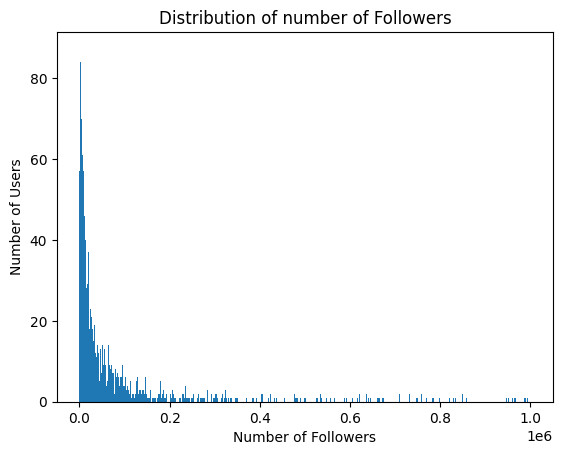

Number of users with following greater than 10000: 73


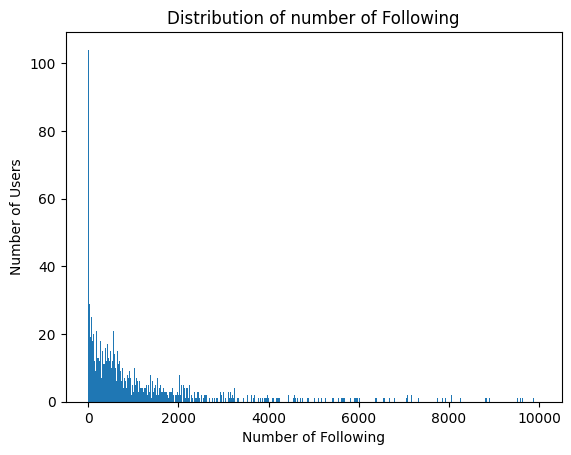

In [67]:
# plotting histogram of different features
import matplotlib.pyplot as plt

# plotting histogram of followers, taking range till 10,00,000 since only 99 users have followers greater than 10,00,000
print("Number of users with followers greater than 1000000:", len(data[data['followers'] > 1000000]))
followers_plt = plt.hist(data['followers'], bins=900, range=(0, 1000000))
plt.title('Distribution of number of Followers')
plt.xlabel('Number of Followers')
plt.ylabel('Number of Users')
plt.show()

# plotting histogram of following
print("Number of users with following greater than 10000:", len(data[data['following'] > 10000]))
following_plt = plt.hist(data['following'], bins=1000, range=(0, 10000))
plt.title('Distribution of number of Following')
plt.xlabel('Number of Following')
plt.ylabel('Number of Users')
plt.show()



